# DINO Feature Visualization
Visualize train/test features from `OUTPUT_DINO/features/` using PCA and t-SNE.

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

FEATURES_DIR = "OUTPUT_DINO/features"
CLASS_NAMES = ["Cats", "Dogs"]  # adjust if needed

In [20]:
train_feats  = torch.load(f"{FEATURES_DIR}/trainfeat.pth").numpy()
test_feats   = torch.load(f"{FEATURES_DIR}/testfeat.pth").numpy()
train_labels = torch.load(f"{FEATURES_DIR}/trainlabels.pth").numpy()
test_labels  = torch.load(f"{FEATURES_DIR}/testlabels.pth").numpy()

print(f"Train: {train_feats.shape}, labels: {np.unique(train_labels)}")
print(f"Test:  {test_feats.shape},  labels: {np.unique(test_labels)}")

Train: (19998, 384), labels: [0 1]
Test:  (5000, 384),  labels: [0 1]


## Label distribution

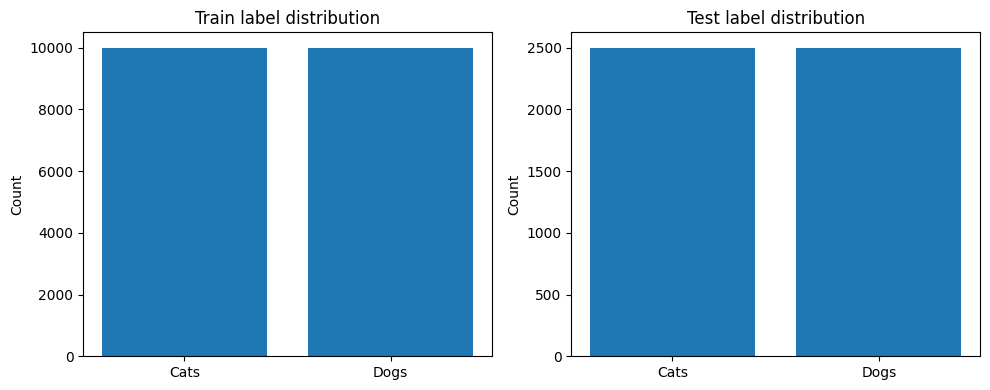

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, labels, title in zip(axes, [train_labels, test_labels], ["Train", "Test"]):
    counts = np.bincount(labels)
    ax.bar(CLASS_NAMES[:len(counts)], counts)
    ax.set_title(f"{title} label distribution")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## PCA (2D)

In [22]:
pca = PCA(n_components=2)
train_pca = pca.fit_transform(train_feats)
test_pca  = pca.transform(test_feats)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Explained variance ratio: [0.11156883 0.0965649 ]


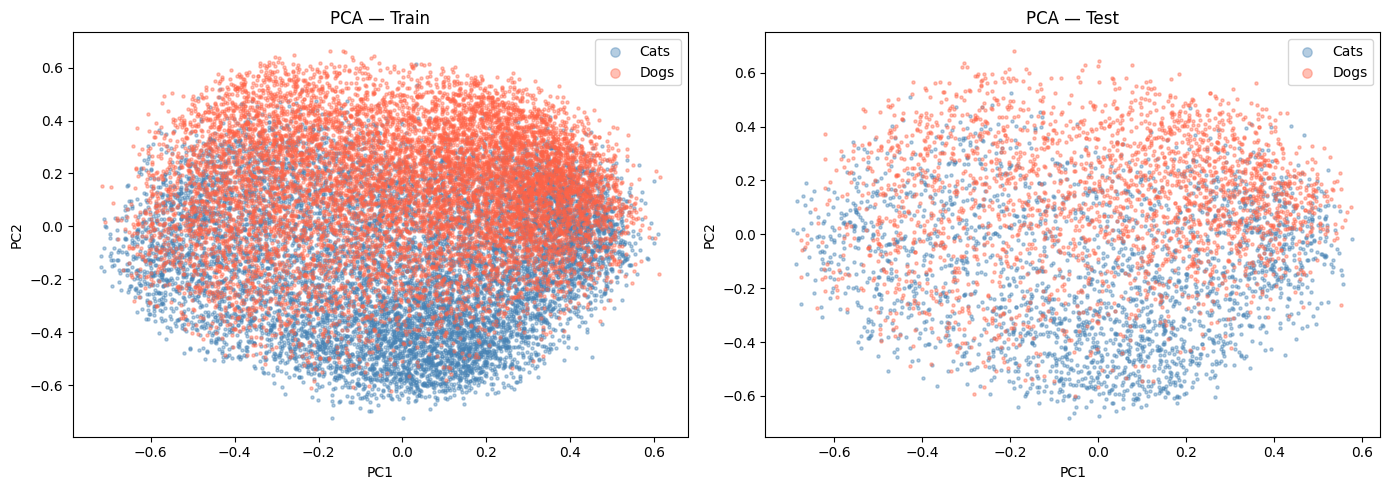

In [23]:
colors = ["steelblue", "tomato"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, emb, labels, title in zip(
    axes,
    [train_pca, test_pca],
    [train_labels, test_labels],
    ["Train", "Test"]
):
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = labels == cls_id
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=colors[cls_id], label=cls_name,
                   alpha=0.4, s=5, rasterized=True)
    ax.set_title(f"PCA — {title}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig("OUTPUT_DINO/features/pca.png", dpi=150)
plt.show()

## PCA (3D)

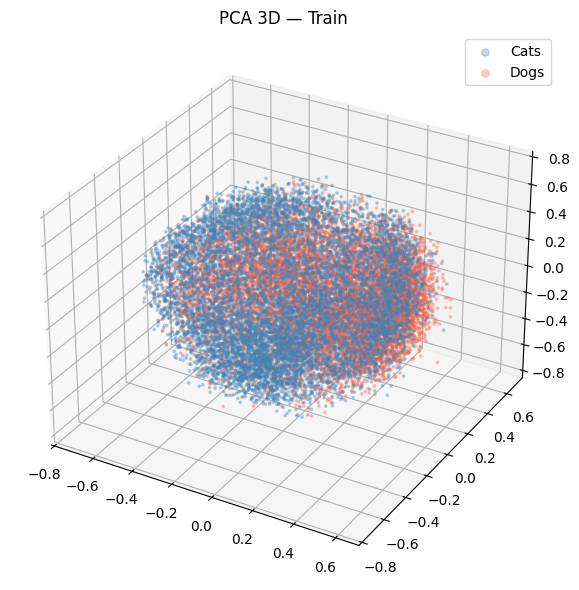

In [24]:
pca3 = PCA(n_components=3)
train_pca3 = pca3.fit_transform(train_feats)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask = train_labels == cls_id
    ax.scatter(train_pca3[mask, 0], train_pca3[mask, 1], train_pca3[mask, 2],
               c=colors[cls_id], label=cls_name, alpha=0.3, s=3, rasterized=True)
ax.set_title("PCA 3D — Train")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

## t-SNE (2D)
Runs on a subsample for speed — adjust `N_SAMPLES` as needed.

In [25]:
N_SAMPLES = 5000  # increase for more detail, decrease for speed
rng = np.random.default_rng(42)

# Subsample
idx_tr = rng.choice(len(train_feats), min(N_SAMPLES, len(train_feats)), replace=False)
idx_te = rng.choice(len(test_feats),  min(N_SAMPLES, len(test_feats)),  replace=False)

# Run t-SNE on PCA-reduced features (speeds up t-SNE significantly)
pca50 = PCA(n_components=50)
tr50 = pca50.fit_transform(train_feats[idx_tr])
te50 = pca50.fit_transform(test_feats[idx_te])

print("Running t-SNE on train subset...")
tsne_tr = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1).fit_transform(tr50)
print("Running t-SNE on test subset...")
tsne_te = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1).fit_transform(te50)

Running t-SNE on train subset...
Running t-SNE on test subset...


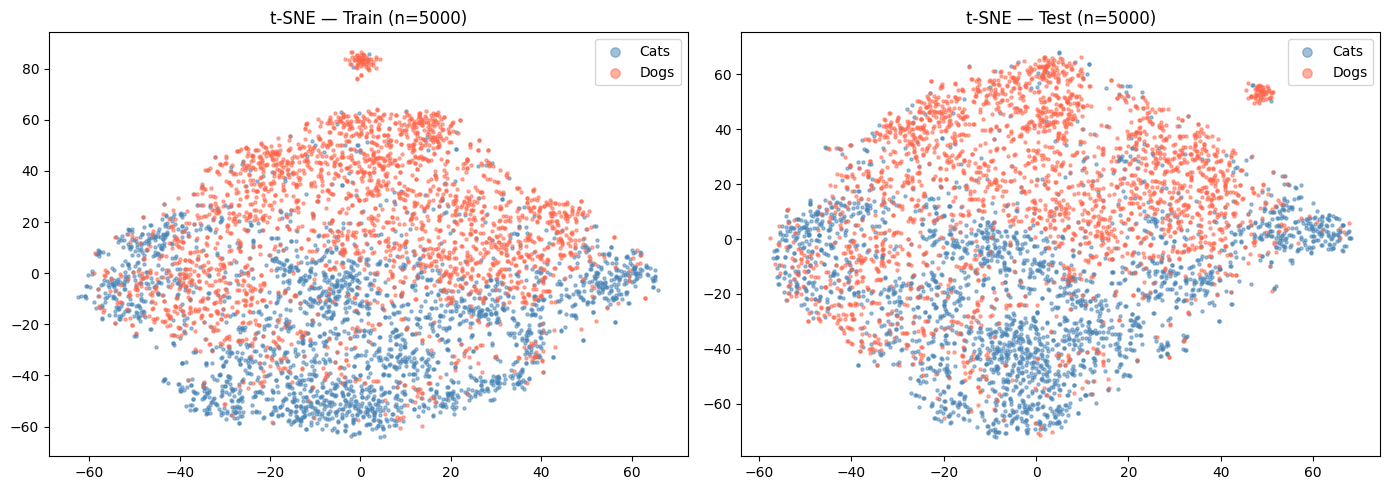

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, emb, labels, idx, title in zip(
    axes,
    [tsne_tr, tsne_te],
    [train_labels, test_labels],
    [idx_tr, idx_te],
    ["Train", "Test"]
):
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = labels[idx] == cls_id
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=colors[cls_id], label=cls_name,
                   alpha=0.5, s=5, rasterized=True)
    ax.set_title(f"t-SNE — {title} (n={len(idx)})")
    ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig("OUTPUT_DINO/features/tsne.png", dpi=150)
plt.show()

## Cosine similarity between class centroids

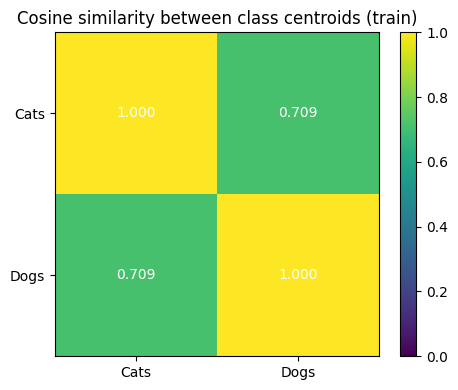

In [27]:
from sklearn.metrics.pairwise import cosine_similarity

centroids = np.stack([
    train_feats[train_labels == cls_id].mean(axis=0)
    for cls_id in range(len(CLASS_NAMES))
])

sim = cosine_similarity(centroids)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, f"{sim[i, j]:.3f}", ha="center", va="center", color="white")
plt.colorbar(im, ax=ax)
ax.set_title("Cosine similarity between class centroids (train)")
plt.tight_layout()
plt.show()